## ⚙️ Setup Instructions: Run Neo4j Locally via CLI (Community Edition)

This setup lets you run Neo4j fully on your local machine and connect from this notebook using the Bolt protocol.

---

### ✅ 1. Install Neo4j (Linux)

```bash
# Add the Neo4j package key and repository
wget -O - https://debian.neo4j.com/neotechnology.gpg.key | sudo apt-key add -
echo 'deb https://debian.neo4j.com stable 5' | sudo tee /etc/apt/sources.list.d/neo4j.list

# Update and install
sudo apt update
sudo apt install neo4j
```

---

### 🔐 2. Set Initial Password

```bash
sudo neo4j-admin dbms set-initial-password neo4j123
```

This sets the password for the default user `neo4j`.

---

### ▶️ 3. Start the Neo4j Server

```bash
sudo neo4j start
```

---


### ⚙️ Setup Neo4j Connection

Connect to your Neo4j instance using the official Python driver.
Replace credentials with your own if needed.


In [7]:
!pip install neo4j --quiet

from neo4j import GraphDatabase

# 🔐 Replace with your own connection details
NEO4J_URI = "bolt://localhost:7687"      # Or your Neo4j Aura DB URI
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "neo4j123"              # Replace with your password

# Create the Neo4j driver
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))


### 📥 Canonicalized Triplets for Ingestion

This step prepares the foundational data used to construct the graph.

**Steps:**

1. Define a list of canonical triplets representing relationships between entities:
   - Example: `Customer → reports → Issue`
   - All entities should be normalized and schema-aligned (e.g., `Battery Drain` instead of `Battery Drain Issue`)

2. Define a dictionary of node metadata to enrich individual nodes with attributes:
   - Customers include `customer_id` and `ticket_id`
   - Issues include `ticket_date`
   - Resolutions include `released_on` dates

3. These triplets and attributes will be loaded into Neo4j to form a queryable knowledge graph structure.


In [8]:
triplets = [
    # Ticket 1
    ("Customer 2345", "has_ticket", "TKT-001"),
    ("TKT-001", "reports", "Battery Drain"),
    ("TKT-001", "resolved_by", "Patch 1.2.1"),

    # Ticket 2
    ("Customer 7781", "has_ticket", "TKT-002"),
    ("TKT-002", "reports", "Battery Drain"),

    # Ticket 3
    ("Customer 3464", "has_ticket", "TKT-003"),
    ("TKT-003", "reports", "Battery Drain"),

    # Shared issue context
    ("Battery Drain", "affects", "Laptop Model X"),
    ("Battery Drain", "caused_by", "Update v1.2")
]




node_properties = {
    # Customers
    "Customer 2345": {"type": "Customer", "customer_id": 2345},
    "Customer 7781": {"type": "Customer", "customer_id": 7781},
    "Customer 3464": {"type": "Customer", "customer_id": 3464},

    # Tickets
    "TKT-001": {"type": "Ticket", "ticket_date": "2023-10-08"},
    "TKT-002": {"type": "Ticket", "ticket_date": "2023-10-09"},
    "TKT-003": {"type": "Ticket", "ticket_date": "2023-10-09"},

    # Entities
    "Battery Drain": {"type": "Issue"},
    "Laptop Model X": {"type": "Product"},
    "Update v1.2": {"type": "Cause"},
    "Patch 1.2.1": {"type": "Resolution", "released_on": "2023-10-10"}
}


### 🗂️ Step: Store Triplets and Enrich Node Properties in Neo4j

This step does two things:

1. **Ingest structured triplets** into the Neo4j graph using `MERGE` to create nodes and relationships.

2. **Enrich each node** with its associated metadata (if available), using the `SET` clause to assign properties such as:
   - `type`
   - `customer_id`
   - `ticket_id`
   - `released_on`
   - `ticket_date`

This ensures both structure and context are captured in the graph.


In [9]:
def store_triplets_and_properties(tx, triplets, node_props):
    # Cache labels for fast lookup
    label_lookup = {k: v.get("type", "Entity") for k, v in node_props.items()}

    # Create relationships only if labels can be resolved
    for subj, pred, obj in triplets:
        subj_label = label_lookup.get(subj)
        obj_label = label_lookup.get(obj)

        # Skip nodes not defined in node_props (e.g., literal values like dates)
        if not subj_label or not obj_label:
            print(f"⚠️ Skipping relationship: ({subj})-[:{pred}]->({obj}) — missing label(s)")
            continue

        query = f"""
        MERGE (a:{subj_label} {{name: '{subj}'}})
        MERGE (b:{obj_label} {{name: '{obj}'}})
        MERGE (a)-[:{pred.upper()}]->(b)
        """
        tx.run(query)

    # Enrich nodes with properties
    for node_name, props in node_props.items():
        label = props.get("type", "Entity")
        filtered_props = {k: v for k, v in props.items() if k != "type"}

        prop_query = f"MERGE (n:{label} {{name: '{node_name}'}})"
        if filtered_props:
            set_clause = ", ".join([
                f"n.{key} = {value}" if isinstance(value, int) else f"n.{key} = '{value}'"
                for key, value in filtered_props.items()
            ])
            prop_query += f"\nSET {set_clause}"

        tx.run(prop_query)





with driver.session() as session:
    session.execute_write(store_triplets_and_properties, triplets, node_properties)


### 🧠 Use Case — Reasoning Path for a New Inquiry About Battery Drain

- Start with a new inquiry about the "Battery Drain" issue.
- Query and visualize the resolved ticket:
  - Show customer, ticket, issue, product, and resolution.
  - Highlight path in green.
- Retrieve and overlay all related tickets reporting the same issue:
  - Include unresolved tickets.
  - Show unresolved tickets and their customers in red.
- All tickets connect to the same issue and product.
- The agent can reference the known resolution (e.g., Patch 1.2.1) for unresolved cases.
- The graph shows how prior evidence supports reasoning, even without direct resolution links.


In [10]:
records = []

with driver.session() as session:
    result = session.run("""
        MATCH (i:Issue {name: 'Battery Drain'})-[:AFFECTS]->(p:Product)
        MATCH (c:Customer)-[:HAS_TICKET]->(t:Ticket)-[:REPORTS]->(i)
        MATCH (t)-[:RESOLVED_BY]->(r:Resolution)
        RETURN c.name AS customer, t.name AS ticket,
               i.name AS issue, p.name AS product,
               r.name AS resolution, r.released_on AS patch_date,
               t.ticket_date AS ticket_date
    """)
    for record in result:
        records.append(record)
        print(dict(record))


{'customer': 'Customer 2345', 'ticket': 'TKT-001', 'issue': 'Battery Drain', 'product': 'Laptop Model X', 'resolution': 'Patch 1.2.1', 'patch_date': '2023-10-10', 'ticket_date': '2023-10-08'}


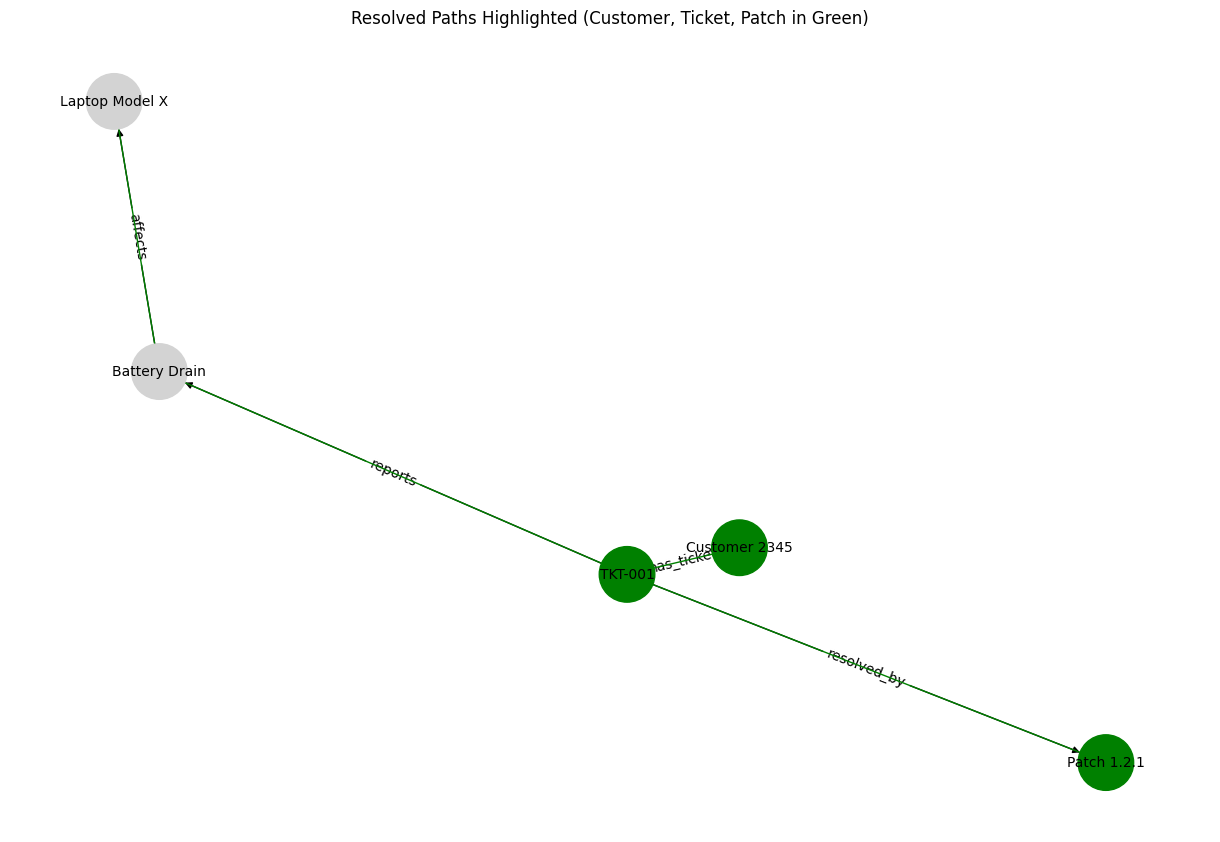

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
resolved_tickets = set()
resolution_nodes = set()
resolved_customers = set()

# Build graph and track resolved chains
for rec in records:
    cust = rec["customer"]
    ticket = rec["ticket"]
    issue = rec["issue"]
    product = rec["product"]
    resolution = rec["resolution"]

    G.add_edge(cust, ticket, label="has_ticket")
    G.add_edge(ticket, issue, label="reports")
    G.add_edge(issue, product, label="affects")

    if resolution:
        G.add_edge(ticket, resolution, label="resolved_by")
        resolution_nodes.add(resolution)
        resolved_tickets.add(ticket)
        resolved_customers.add(cust)

# Layout
pos = nx.spring_layout(G, seed=42)

# Assign node colors
node_colors = []
for node in G.nodes():
    if node in resolution_nodes or node in resolved_tickets or node in resolved_customers:
        node_colors.append("green")
    else:
        node_colors.append("lightgray")

# Draw
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=1600, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"))
nx.draw_networkx_edges(G, pos, edge_color="green", arrows=True)

plt.title("Resolved Paths Highlighted (Customer, Ticket, Patch in Green)")
plt.axis("off")
plt.show()


In [12]:
# Run a second query and collect new records (already done)
new_records = []

with driver.session() as session:
    result = session.run("""
        MATCH (i:Issue {name: 'Battery Drain'})-[:AFFECTS]->(p:Product)
        MATCH (c:Customer)-[:HAS_TICKET]->(t:Ticket)-[:REPORTS]->(i)
        OPTIONAL MATCH (t)-[:RESOLVED_BY]->(r:Resolution)
        RETURN c.name AS customer, t.name AS ticket,
               i.name AS issue, p.name AS product,
               r.name AS resolution, r.released_on AS patch_date,
               t.ticket_date AS ticket_date
    """)
    for record in result:
        new_records.append(record)
        print(dict(record))



{'customer': 'Customer 2345', 'ticket': 'TKT-001', 'issue': 'Battery Drain', 'product': 'Laptop Model X', 'resolution': 'Patch 1.2.1', 'patch_date': '2023-10-10', 'ticket_date': '2023-10-08'}
{'customer': 'Customer 7781', 'ticket': 'TKT-002', 'issue': 'Battery Drain', 'product': 'Laptop Model X', 'resolution': None, 'patch_date': None, 'ticket_date': '2023-10-09'}
{'customer': 'Customer 3464', 'ticket': 'TKT-003', 'issue': 'Battery Drain', 'product': 'Laptop Model X', 'resolution': None, 'patch_date': None, 'ticket_date': '2023-10-09'}


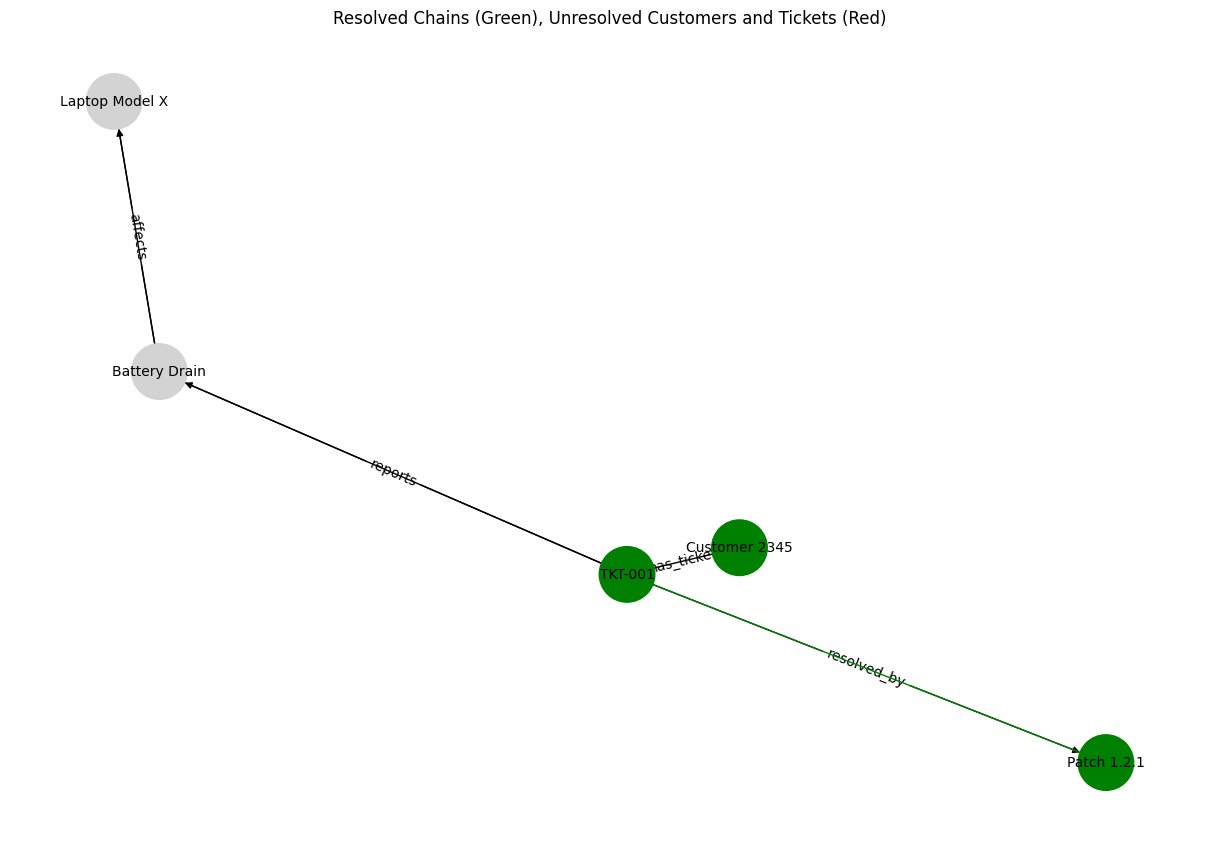

In [13]:
# Track node roles using new_records (no changes to G)
unresolved_tickets = set()
resolved_tickets = set()
resolved_customers = set()
unresolved_customers = set()
resolution_nodes = set()

for rec in new_records:
    cust = rec["customer"]
    ticket = rec["ticket"]
    resolution = rec["resolution"]

    if resolution:
        resolved_tickets.add(ticket)
        resolved_customers.add(cust)
        resolution_nodes.add(resolution)
    else:
        unresolved_tickets.add(ticket)
        unresolved_customers.add(cust)

# Layout update for any new nodes (if any)
new_pos = nx.spring_layout(G, seed=42, pos=pos, fixed=pos.keys())
pos.update(new_pos)

# Assign node colors based on status
node_colors = []
for node in G.nodes():
    if node in resolution_nodes or node in resolved_tickets or node in resolved_customers:
        node_colors.append("green")
    elif node in unresolved_tickets or node in unresolved_customers:
        node_colors.append("red")
    else:
        node_colors.append("lightgray")

# Draw graph with updated colors
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=1600, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"))

# Edge coloring logic
for u, v in G.edges():
    label = G[u][v]["label"]
    edge_color = "green" if label == "resolved_by" else "black"
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        edge_color=edge_color,
        style="solid",
        arrows=True
    )

plt.title("Resolved Chains (Green), Unresolved Customers and Tickets (Red)")
plt.axis("off")
plt.show()
